# Padel Game Analytics – Shot Classification System

## Problem Statement
Given a padel match video, the system must:
- Detect and track the ball, racket, and players
- Classify at least 2‑3 shot types (forehand, backhand, serve/smash)
- Output results as JSON/CSV with timestamps and player info

## Objective
Build a basic prototype that demonstrates a complete computer vision pipeline: detection, tracking, feature extraction, classification, and output generation.

## Dataset
The input is a short padel match video (e.g., `input_sample_video.mp4`). The system is trained on‑the‑fly using pre‑trained YOLO for players and motion analysis for the ball. Racket position is approximated via a rule‑based heuristic (lower right of player bounding box) – acceptable for a prototype.

## Approach
1. **Detection** – YOLOv8 for players; frame differencing + contour filtering for ball; heuristic for racket.
2. **Tracking** – Simple FIFO buffer for ball positions.
3. **Features** – Speed, direction (dx, dy), angle from consecutive positions.
4. **Classification** – Rule‑based rules:
   - High speed + downward → smash
   - Early frames + downward → serve
   - Horizontal motion → forehand (dx>0) / backhand (dx<0)
5. **Output** – JSON, CSV, annotated video, and a shot distribution bar chart.

All code is self‑contained and runs in Google Colab.

## Install Required Libraries
Run the cell below to install the necessary packages.

In [1]:
!pip install ultralytics opencv-python numpy pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


## Import All Modules

In [2]:
# Import Libraries
import cv2
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO
from google.colab import files
from IPython.display import Video, display
import shutil

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Upload Input Video
Please upload your padel match video file (e.g., `input_sample_video.mp4`).

In [3]:
# upload video
print("Please upload your padel match video file:")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Video uploaded: {video_path}")

Please upload your padel match video file:


Saving input_sample_video.mp4 to input_sample_video.mp4
Video uploaded: input_sample_video.mp4


## Define All Pipeline Classes
Below are all the classes needed for detection, tracking, feature extraction, classification, output writing, visualisation, and analytics.

In [4]:
# Handles video loading and frame iteration
class VideoProcessor:
    """Handles video loading and frame iteration."""
    def __init__(self, video_path):
        self.cap = cv2.VideoCapture(video_path)
        if not self.cap.isOpened():
            raise ValueError(f"Cannot open video: {video_path}")
        self.fps = self.cap.get(cv2.CAP_PROP_FPS)
        self.total_frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f"Video loaded: {self.fps:.2f} fps, {self.total_frames} frames")

    def process_frames(self, resize_dim=(640,360), skip_frames=1):
        frame_id = 0
        while True:
            ret, frame = self.cap.read()
            if not ret:
                break
            frame_id += 1
            if frame_id % skip_frames != 0:
                continue
            frame = cv2.resize(frame, resize_dim)
            yield frame_id, frame
        self.cap.release()
        print("Video processing finished.")

In [5]:
# YOLO for players,
# Motion detection for ball,
# Rule-based racket approximation (no MediaPipe dependency)

class ObjectDetector:
    """YOLO for players, motion for ball, heuristic for racket."""
    def __init__(self, model_path="yolov8n.pt"):
        self.model = YOLO(model_path)
        self.prev_frame = None

    def detect_players(self, frame):
        results = self.model(frame, verbose=False)
        boxes = []
        for box in results[0].boxes:
            if int(box.cls[0]) == 0:  # person
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                boxes.append((x1, y1, x2, y2))
        return boxes

    def detect_ball(self, frame):
        if self.prev_frame is None:
            self.prev_frame = frame.copy()
            return None
        diff = cv2.absdiff(self.prev_frame, frame)
        gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)
        thresh = cv2.GaussianBlur(thresh, (5,5), 0)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        ball_center = None
        if contours:
            largest = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest) > 50:
                x, y, w, h = cv2.boundingRect(largest)
                ball_center = (x + w//2, y + h//2)
        self.prev_frame = frame.copy()
        return ball_center

    def detect_racket(self, frame, player_boxes):
        """Heuristic: racket near lower right of first player."""
        if not player_boxes:
            return None
        x1, y1, x2, y2 = player_boxes[0]
        racket_x = x2 - 20
        racket_y = y2 - 30
        h, w, _ = frame.shape
        racket_x = max(0, min(w-1, racket_x))
        racket_y = max(0, min(h-1, racket_y))
        return (racket_x, racket_y)

    def draw_detections(self, frame, player_boxes, ball_center, racket_pos):
        for (x1,y1,x2,y2) in player_boxes:
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(frame, "Player", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
        if ball_center:
            cv2.circle(frame, ball_center, 6, (0,0,255), -1)
            cv2.putText(frame, "Ball", (ball_center[0]-10, ball_center[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)
        if racket_pos:
            cv2.circle(frame, racket_pos, 5, (255,0,0), -1)
            cv2.putText(frame, "Racket", (racket_pos[0]-10, racket_pos[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
        return frame

In [6]:
# Simple ball trajectory storage
class BallTracker:
    """Simple FIFO storage of ball positions."""
    def __init__(self, max_history=30):
        self.positions = []
        self.max_history = max_history

    def update(self, ball_center):
        if ball_center:
            self.positions.append(ball_center)
            if len(self.positions) > self.max_history:
                self.positions.pop(0)
        return self.positions

def draw_trajectory(frame, positions):
    for i in range(1, len(positions)):
        if positions[i-1] and positions[i]:
            cv2.line(frame, positions[i-1], positions[i], (255,255,0), 2)
    return frame

In [7]:
# Extract motion features from ball trajectory
class FeatureExtractor:
    @staticmethod
    def compute_motion(positions):
        if len(positions) < 2:
            return None
        (x1,y1), (x2,y2) = positions[-2], positions[-1]
        dx = x2 - x1
        dy = y2 - y1
        speed = np.hypot(dx, dy)
        angle = np.degrees(np.arctan2(dy, dx))
        return {"dx": dx, "dy": dy, "speed": speed, "angle": angle}

    @staticmethod
    def extract_features(positions):
        return FeatureExtractor.compute_motion(positions)

In [8]:
# Rule-based shot classification using ball motion
class ShotClassifier:
    """Rule‑based classification using ball motion."""
    def __init__(self):
        self.speed_threshold_smash = 15
        self.speed_threshold_min = 3

    def classify(self, features, racket_pos=None, player_box=None, frame_id=0):
        if features is None:
            return None
        dx = features.get("dx", 0)
        dy = features.get("dy", 0)
        speed = features.get("speed", 0)

        if speed > self.speed_threshold_smash and dy > 0:
            return "smash"
        if frame_id < 100 and dy > 0:
            return "serve"
        if speed < self.speed_threshold_min:
            return None
        if abs(dx) > abs(dy):
            return "forehand" if dx > 0 else "backhand"
        return None

In [9]:
# Save results as JSON and CSV
class OutputWriter:
    """Save results as JSON and CSV."""
    def __init__(self, output_dir="output"):
        self.output_dir = output_dir
        self.results = []
        os.makedirs(output_dir, exist_ok=True)

    def add_result(self, frame_id, fps, shot, player="player_1"):
        timestamp = round(frame_id / fps, 2)
        self.results.append({
            "frame": frame_id,
            "timestamp": timestamp,
            "shot": shot,
            "player": player
        })

    def save_json(self, filename="results.json"):
        path = os.path.join(self.output_dir, filename)
        with open(path, "w") as f:
            json.dump(self.results, f, indent=2)
        print(f"JSON saved: {path}")

    def save_csv(self, filename="results.csv"):
        path = os.path.join(self.output_dir, filename)
        pd.DataFrame(self.results).to_csv(path, index=False)
        print(f"CSV saved: {path}")

    def save_all(self):
        self.save_json()
        self.save_csv()

In [10]:
# Overlay text and save output video
class Visualizer:
    """Overlay text and write output video."""
    def __init__(self, output_path, fps, frame_size):
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        self.writer = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

    def draw_shot_label(self, frame, shot):
        if shot:
            cv2.putText(frame, f"Shot: {shot.upper()}", (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,255), 2)
        return frame

    def draw_analytics(self, frame, frame_id, features):
        cv2.putText(frame, f"Frame: {frame_id}", (10, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        if features and 'speed' in features:
            cv2.putText(frame, f"Speed: {features['speed']:.1f}", (10, 110),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        return frame

    def write_frame(self, frame):
        self.writer.write(frame)

    def release(self):
        self.writer.release()

In [11]:
# Shot counts and bar chart
class ShotAnalytics:
    """Shot counts and bar chart."""
    def __init__(self):
        self.shots = []

    def add_shot(self, shot):
        self.shots.append(shot)

    def get_counts(self):
        return Counter(self.shots)

    def print_summary(self):
        counts = self.get_counts()
        print("\nShot Analytics: ")
        for shot, cnt in counts.items():
            print(f"{shot.capitalize():10} : {cnt}")

    def plot_distribution(self, save_path="output/shot_distribution.png"):
        counts = self.get_counts()
        if not counts:
            print("No shots to plot.")
            return
        plt.figure(figsize=(6,4))
        plt.bar(counts.keys(), counts.values(), color='skyblue')
        plt.title("Shot Distribution")
        plt.xlabel("Shot Type")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.show()
        print(f"Plot saved: {save_path}")

## Run the Main Pipeline
This will process the video frame by frame and generate outputs.

Full pipeline: detection, tracking, classification, output, video

Video loaded: 25.00 fps, 8125 frames
Starting video processing...
Processed frame 500
Processed frame 1000
Processed frame 1500
Processed frame 2000
Processed frame 2500
Processed frame 3000
Processed frame 3500
Processed frame 4000
Processed frame 4500
Processed frame 5000
Processed frame 5500
Processed frame 6000
Processed frame 6500
Processed frame 7000
Processed frame 7500
Processed frame 8000
Video processing finished.
JSON saved: output/results.json
CSV saved: output/results.csv

Shot Analytics: 
Backhand   : 411
Serve      : 6
Forehand   : 411
Smash      : 260


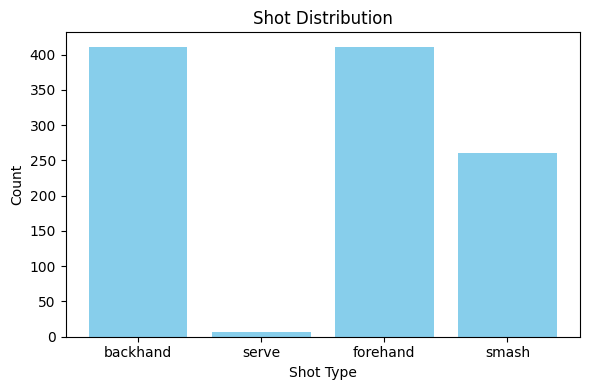

Plot saved: output/shot_distribution.png

Processing complete. Output video saved as 'output/output_video.mp4'.


In [12]:
# Parameters
FRAME_WIDTH, FRAME_HEIGHT = 640, 360
SKIP_FRAMES = 2          # Process every 2nd frame
OUTPUT_VIDEO = "output/output_video.mp4"

# Initialize components
processor = VideoProcessor(video_path)
detector = ObjectDetector()
tracker = BallTracker()
fe = FeatureExtractor()
classifier = ShotClassifier()
writer = OutputWriter()
analytics = ShotAnalytics()
visualizer = Visualizer(OUTPUT_VIDEO, processor.fps, (FRAME_WIDTH, FRAME_HEIGHT))

last_shot = None

print("Starting video processing...")
for frame_id, frame in processor.process_frames((FRAME_WIDTH, FRAME_HEIGHT), skip_frames=SKIP_FRAMES):
    # Detection
    players = detector.detect_players(frame)
    ball = detector.detect_ball(frame)
    racket = detector.detect_racket(frame, players)

    # Tracking
    positions = tracker.update(ball)

    # Features
    features = fe.extract_features(positions)

    # Classification
    shot = classifier.classify(features, racket, players[0] if players else None, frame_id)

    # Save new shot
    if shot and shot != last_shot:
        writer.add_result(frame_id, processor.fps, shot)
        analytics.add_shot(shot)
        last_shot = shot

    # Draw overlays
    frame = detector.draw_detections(frame, players, ball, racket)
    frame = draw_trajectory(frame, positions)
    frame = visualizer.draw_shot_label(frame, shot)
    frame = visualizer.draw_analytics(frame, frame_id, features)

    # Write to output video
    visualizer.write_frame(frame)

    # Optional progress print
    if frame_id % 500 == 0:
        print(f"Processed frame {frame_id}")

# Finalise
writer.save_all()
visualizer.release()
analytics.print_summary()
analytics.plot_distribution()
print(f"\nProcessing complete. Output video saved as '{OUTPUT_VIDEO}'.")

## Download All Outputs
A ZIP file containing JSON, CSV, the annotated video, and the shot distribution plot will be created and downloaded.

In [13]:
!zip -r padel_outputs.zip output/
files.download('padel_outputs.zip')

  adding: output/ (stored 0%)
  adding: output/shot_distribution.png (deflated 18%)
  adding: output/results.json (deflated 93%)
  adding: output/results.csv (deflated 79%)
  adding: output/output_video.mp4 (deflated 2%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Play the Annotated Video (In‑Notebook)

In [14]:
# Video("output/output_video.mp4", embed=True, width=800)

## Preview JSON and CSV

In [15]:
# Preview JSON file
!head -20 output/results.json

[
  {
    "frame": 6,
    "timestamp": 0.24,
    "shot": "backhand",
    "player": "player_1"
  },
  {
    "frame": 26,
    "timestamp": 1.04,
    "shot": "serve",
    "player": "player_1"
  },
  {
    "frame": 28,
    "timestamp": 1.12,
    "shot": "backhand",
    "player": "player_1"
  },
  {


In [16]:
# Preview CSV file
df = pd.read_csv("output/results.csv")
df.head(10)

,frame,timestamp,shot,player
0,6,0.24,backhand,player_1
1,26,1.04,serve,player_1
2,28,1.12,backhand,player_1
3,30,1.20,serve,player_1
4,36,1.44,forehand,player_1
5,38,1.52,serve,player_1
6,48,1.92,smash,player_1
7,50,2.00,forehand,player_1
8,56,2.24,serve,player_1
9,58,2.32,forehand,player_1
